# Task 1: Data Augmentation

## Importing libraries and Dataset

In [23]:
# !pip install --upgrade augly -q

In [6]:
import os
import random
import requests
import numpy as np
import pandas as pd
from PIL import Image
import augly.image as imaugs
from augly.image.composition import Compose
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.optim as optim
from torch.optim import Adam
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision import models
from torchsummary import summary
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix
import seaborn as sns

In [7]:
import kagglehub

# Downloading latest version
path = kagglehub.dataset_download("samuelcortinhas/cats-and-dogs-image-classification")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\borat\.cache\kagglehub\datasets\samuelcortinhas\cats-and-dogs-image-classification\versions\4


In [10]:
cats_dir = os.path.join(path, 'test', 'cats')
dogs_dir = os.path.join(path, 'test', 'dogs')

# Function to display random images in a single row subplot
def display_random_images(image_dir, num_images=3):
    # Listing of all image files in the directory
    image_files = os.listdir(image_dir)

    # Selecting random images
    random_images = random.sample(image_files, min(num_images, len(image_files)))

    # Creating a subplot with selected images
    fig, axes = plt.subplots(1, len(random_images), figsize=(15, 5))

    for ax, img_file in zip(axes, random_images):
        img_path = os.path.join(image_dir, img_file)  # Get full image path
        img = Image.open(img_path)  # Open image
        ax.imshow(img)  # Display image
        ax.set_title(img_file)
        ax.axis('off')

    plt.show()

# Displaying cat images
print("Cat Images:")
display_random_images(cats_dir)

# Displaying dog images
print("\nDog Images:")
display_random_images(dogs_dir)

Cat Images:


ValueError: Number of columns must be a positive integer, not 0

<Figure size 1500x500 with 0 Axes>

## Organizing contents in directories

In [1]:
# Defining paths for training and testing sets
base_dir = "/content/dataset"  # Main dataset directory
train_dir = os.path.join(base_dir, "train")  # Training data directory
test_dir = os.path.join(base_dir, "test")  # Testing data directory

train_cats_dir = os.path.join(train_dir, "cats")
test_cats_dir = os.path.join(test_dir, "cats")
train_dogs_dir = os.path.join(train_dir, "dogs")
test_dogs_dir = os.path.join(test_dir, "dogs")

# Ensuring directories exist
os.makedirs(train_cats_dir, exist_ok=True)
os.makedirs(test_cats_dir, exist_ok=True)
os.makedirs(train_dogs_dir, exist_ok=True)
os.makedirs(test_dogs_dir, exist_ok=True)

print(f"Train Cats: {train_cats_dir}")
print(f"Test Cats: {test_cats_dir}")
print(f"Train Dogs: {train_dogs_dir}")
print(f"Test Dogs: {test_dogs_dir}")


NameError: name 'os' is not defined

In [5]:
# Function to split dataset into train (80%) and test (20%) and create directories
def split_dataset(image_dir, train_dir, test_dir, split_ratio=0.8):
    os.makedirs(train_dir, exist_ok=True)
    os.makedirs(test_dir, exist_ok=True)

    image_files = os.listdir(image_dir)
    random.shuffle(image_files)  # Shuffle files
    split_idx = int(len(image_files) * split_ratio)
    train_files = image_files[:split_idx]
    test_files = image_files[split_idx:]

    # Moving the files to respective directories
    for file in train_files:
        os.rename(os.path.join(image_dir, file), os.path.join(train_dir, file))
    for file in test_files:
        os.rename(os.path.join(image_dir, file), os.path.join(test_dir, file))

    return train_dir, test_dir

# Split dataset
train_cats_dir, test_cats_dir = split_dataset(cats_dir, train_cats_dir, test_cats_dir)
train_dogs_dir, test_dogs_dir = split_dataset(dogs_dir, train_dogs_dir, test_dogs_dir)


In [6]:
# Stats before augmentation
train_cats_before = len(os.listdir(train_cats_dir))
train_dogs_before = len(os.listdir(train_dogs_dir))
test_cats_before = len(os.listdir(test_cats_dir))
test_dogs_before = len(os.listdir(test_dogs_dir))

print("Before Augmentation:\n")
print(f"Train Cats: {train_cats_before}")
print(f"Train Dogs: {train_dogs_before}")
print(f"Test Cats: {test_cats_before}")
print(f"Test Dogs: {test_dogs_before}")

print(f"Total Train: {train_cats_before + train_dogs_before}")
print(f"Total Test: {test_cats_before + test_dogs_before}")


Before Augmentation:

Train Cats: 56
Train Dogs: 56
Test Cats: 14
Test Dogs: 14
Total Train: 112
Total Test: 28


## Augmentation Using Augly

For data augmentation, we randomly sampled 3 augmentations from a set of 10 augmentations — pad, scale, rotate, saturation, blur, brightness, skew, random noise, sharpen, and pixelization — and applied these 3 augmentations sequentially to each image. This process is repeated twice for every image.


In [7]:
AUGMENTATIONS = [
    lambda img: imaugs.pad(img),
    lambda img: imaugs.scale(img),
    lambda img: imaugs.rotate(img, degrees=30),
    lambda img: imaugs.saturation(img, factor=1.2),
    lambda img: imaugs.blur(img, radius=2.0),
    lambda img: imaugs.brightness(img, factor=1.2),
    lambda img: imaugs.skew(img),
    lambda img: imaugs.random_noise(img, mean=0.0, var=0.01),
    lambda img: imaugs.sharpen(img, factor = 1.2),
    lambda img: imaugs.pixelization(img, ratio=0.9),
]

In [8]:
def apply_random_augmentations(image_path, output_dir, filename):
    """
    Samples 3 augmentations without replacement TWICE per image,
    applies them sequentially, and saves 3 images (original + 2 augmented versions).
    """
    image = Image.open(image_path).convert("RGB")

    # Sample two sets of 3 augmentations without replacement
    aug_set_1 = random.sample(AUGMENTATIONS, 3)
    aug_set_2 = random.sample(AUGMENTATIONS, 3)

    # Apply augmentations sequentially
    augmented_img1 = image
    for aug in aug_set_1:
        augmented_img1 = aug(augmented_img1)

    augmented_img2 = image
    for aug in aug_set_2:
        augmented_img2 = aug(augmented_img2)

    # Save original and augmented images
    os.makedirs(output_dir, exist_ok=True)
    image.save(os.path.join(output_dir, f"orig_{filename}"))  # Original image
    augmented_img1.save(os.path.join(output_dir, f"aug1_{filename}"))  # Augmentation 1
    augmented_img2.save(os.path.join(output_dir, f"aug2_{filename}"))  # Augmentation 2

In [9]:
def augment_dataset(train_dir, output_dir):
    # Create the output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Loop through each category
    for category in os.listdir(train_dir):
        category_path = os.path.join(train_dir, category)
        output_category_path = os.path.join(output_dir, category)

        # Create a corresponding category directory in the output directory
        os.makedirs(output_category_path, exist_ok=True)

        # Loop through each image file in the category directory
        for filename in os.listdir(category_path):
            image_path = os.path.join(category_path, filename)

            # Apply random augmentations and save the augmented images
            apply_random_augmentations(image_path, output_category_path, filename)


In [10]:
# Example usage
train_dir = "/content/dataset/train"
output_dir = "/content/dataset/aug_train"
augment_dataset(train_dir, output_dir)

Cat Images:


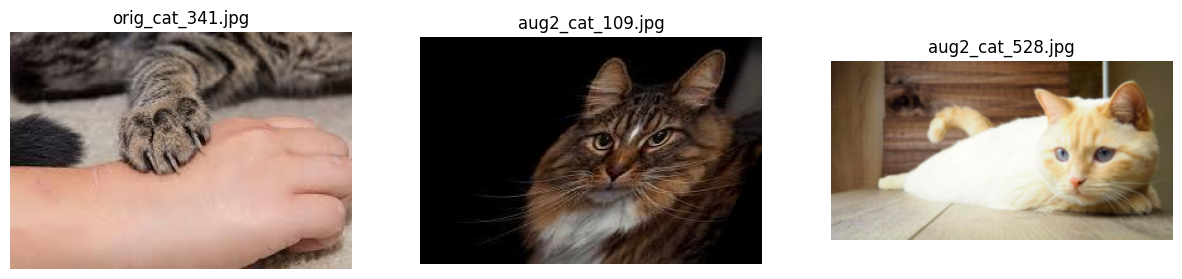


Dog Images:


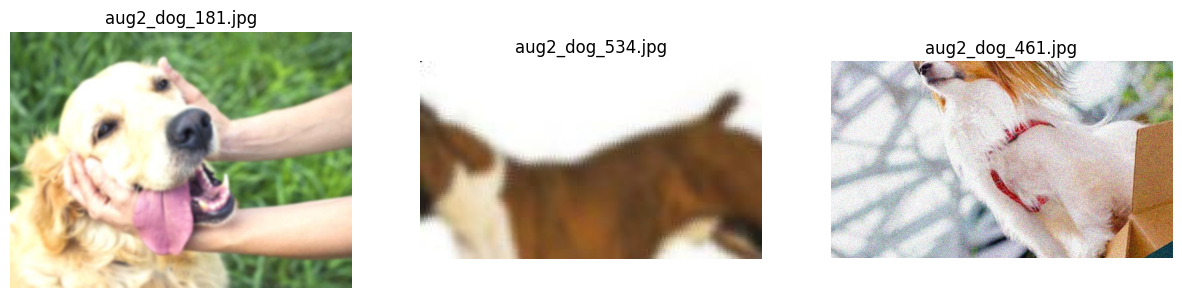

In [11]:
# Example usage
cats_dir2 = "/content/dataset/aug_train/cats"
dogs_dir2 = "/content/dataset/aug_train/dogs"

# Displaying cat images
print("Cat Images:")
display_random_images(cats_dir2)

# Displaying dog images
print("\nDog Images:")
display_random_images(dogs_dir2)


In [12]:
# Stats after augmentation
train_cats_after = len(os.listdir('/content/dataset/aug_train/cats'))
train_dogs_after = len(os.listdir('/content/dataset/aug_train/dogs'))
test_cats_after = len(os.listdir(test_cats_dir)) #remain same
test_dogs_after = len(os.listdir(test_dogs_dir)) #remain same

print("After Augmentation:\n")
print(f"Train Cats: {train_cats_after}")
print(f"Train Dogs: {train_dogs_after}")
print(f"Test Cats: {test_cats_after}")
print(f"Test Dogs: {test_dogs_after}")

print(f"Total Train: {train_cats_after + train_dogs_after}")
print(f"Total Test: {test_cats_after + test_dogs_after}") #remain same


After Augmentation:

Train Cats: 168
Train Dogs: 168
Test Cats: 14
Test Dogs: 14
Total Train: 336
Total Test: 28


## Statistical Comparison of Augmentation

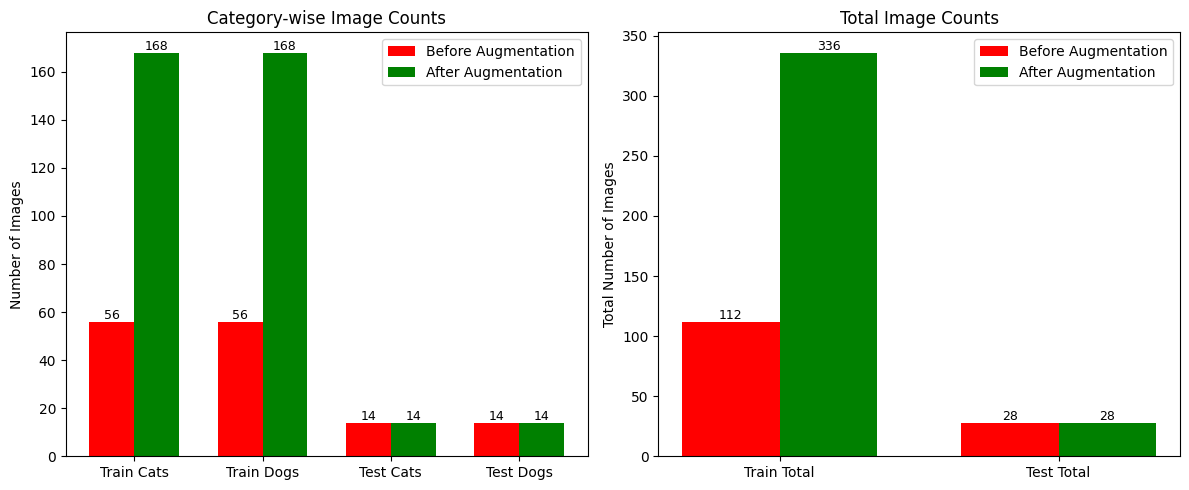

In [13]:
# Data
categories = ['Train Cats', 'Train Dogs', 'Test Cats', 'Test Dogs']
before = [train_cats_before, train_dogs_before, test_cats_before, test_dogs_before]
after = [train_cats_after, train_dogs_after, test_cats_after, test_dogs_after]

# Total counts
total_categories = ['Train Total', 'Test Total']
total_before = [sum(before[:2]), sum(before[2:])]  # Summing train and test separately
total_after = [sum(after[:2]), sum(after[2:])]

x = np.arange(len(categories))
x_total = np.arange(len(total_categories))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# First subplot: Individual categories
axes[0].bar(x - width/2, before, width, label='Before Augmentation', color='red')
axes[0].bar(x + width/2, after, width, label='After Augmentation', color='green')
axes[0].set_ylabel('Number of Images')
axes[0].set_title('Category-wise Image Counts')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()

# Adding labels
for bars in [axes[0].containers[0], axes[0].containers[1]]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     str(bar.get_height()), ha='center', va='bottom', fontsize=9)

# Second subplot: Total counts
axes[1].bar(x_total - width/2, total_before, width, label='Before Augmentation', color='red')
axes[1].bar(x_total + width/2, total_after, width, label='After Augmentation', color='green')
axes[1].set_ylabel('Total Number of Images')
axes[1].set_title('Total Image Counts')
axes[1].set_xticks(x_total)
axes[1].set_xticklabels(total_categories)
axes[1].legend()

# Adding labels
for bars in [axes[1].containers[0], axes[1].containers[1]]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     str(bar.get_height()), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# Task 2: Model Training

In [14]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Directory for saving weights
os.makedirs('saved_models', exist_ok=True)


Resnet-50 architecture:
![Resnet-50 architecture](https://wisdomml.in/wp-content/uploads/2023/03/resnet_bannner.png)

In [15]:
# Hyperparameters
BATCH_SIZE = 8  # Increased for better GPU utilization
NUM_EPOCHS = 10  # More epochs for improved convergence
LEARNING_RATE = 3e-4  # Slightly higher LR for faster learning
IMAGE_SIZE = 224  # Larger input size for more feature extraction


In [16]:
# Define the ResNet50 model class
class ResNet50Model(nn.Module):
    def __init__(self):
        super(ResNet50Model, self).__init__()
        self.resnet50 = models.resnet50(pretrained=False)

        # Modify the last fully connected layer for binary classification (2 output classes)
        num_features = self.resnet50.fc.in_features
        self.resnet50.fc = nn.Linear(num_features, 2)  # Binary classification

    def forward(self, x):
        return self.resnet50(x)

In [17]:
# Ensuring that initial weights of the model are same when training with both datasets

# Initialize the model for the first time
model_1 = ResNet50Model().to(device)

# Save the model's state_dict (weights)
torch.save(model_1.state_dict(), "saved_models/model_weights.pth")

# Initialize the second model
model_2 = ResNet50Model().to(device)

# Load the saved weights into model_2
model_2.load_state_dict(torch.load("saved_models/model_weights.pth"))

c:\Users\borat\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\borat\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
C:\Users\borat\AppData\Local\Temp\ipykernel_30460\746495284.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future 

<All keys matched successfully>

In [18]:
# Summary of the model
summary(model_1, input_size=(3, IMAGE_SIZE, IMAGE_SIZE))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [19]:
# Set up the dataset directories for augmented and non-augmented data
train_dir_aug = '/content/dataset/aug_train'
train_dir_noaug = '/content/dataset/train'
test_dir = '/content/dataset/test'

basic_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),  # Image should also be of same shape as required by resnet-50 architecture
    transforms.ToTensor()  # Automatically normalizes to [0,1]
])

# Load the datasets for augmented and non-augmented training
train_dataset_aug = datasets.ImageFolder(root=train_dir_aug, transform=basic_transforms)
train_dataset_noaug = datasets.ImageFolder(root=train_dir_noaug, transform=basic_transforms)
test_dataset = datasets.ImageFolder(root=test_dir, transform=basic_transforms)

# Create DataLoader for training and testing
train_loader_aug = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True)
train_loader_noaug = DataLoader(train_dataset_noaug, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [20]:
# Train Function
def train_model(model, train_loader, criterion, optimizer, epochs, device):
    model.train()
    losses = []
    metrics = {"accuracy": [], "precision": [], "recall": [], "f1": []}

    for epoch in range(epochs):
        running_loss = 0.0
        correct_predictions = 0
        total_samples = 0
        all_preds = []
        all_labels = []

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward pass & optimization
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Accuracy Calculation
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            # Store predictions & labels for metric calculations
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        # Compute Metrics for this Epoch
        avg_loss = running_loss / len(train_loader)
        accuracy = (correct_predictions / total_samples) * 100
        precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

        # Store Metrics
        losses.append(avg_loss)
        metrics["accuracy"].append(accuracy)
        metrics["precision"].append(precision)
        metrics["recall"].append(recall)
        metrics["f1"].append(f1)

        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%, "
              f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    return losses, metrics

In [21]:
# Define testing function to evaluate the model
def evaluate_model(model, test_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():  # Disable gradient computation for testing
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            # Accuracy Calculation
            _, predicted = torch.max(outputs, 1)
            correct_predictions += (predicted == labels).sum().item()
            total_samples += labels.size(0)

            # Store predictions & labels for later analysis
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Compute Final Test Metrics
    avg_loss = running_loss / len(test_loader)
    accuracy = (correct_predictions / total_samples) * 100
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    # Store metrics in a dictionary
    test_metrics = {
        "loss": avg_loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "labels": all_labels,
        "predictions": all_preds
    }

    print(f"Test Results - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%, "
          f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")

    return test_metrics

## Train and Evaluate Model Without Augmentation

In [22]:
# Set the model_1 to train mode
model_1.train()

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_1.parameters(), lr=LEARNING_RATE)

# Train the model without augmentation
train_losses_noaug, train_metrics_noaug = train_model(model_1, train_loader_noaug, criterion, optimizer, epochs=NUM_EPOCHS, device=device)

# Evaluate the model on the test set
test_metrics_noaug = evaluate_model(model_1, test_loader, criterion, device)

Epoch 1/10 - Loss: 1.0725, Accuracy: 58.04%, Precision: 0.5810, Recall: 0.5804, F1-score: 0.5795
Epoch 2/10 - Loss: 0.7987, Accuracy: 53.57%, Precision: 0.5358, Recall: 0.5357, F1-score: 0.5356


KeyboardInterrupt: 

## Train and evaluate the model with data augmentation

In [ ]:
# Set the model_2 to train mode
model_2.train()

# Define the loss function and optimizer for model_2
optimizer = optim.Adam(model_2.parameters(), lr=LEARNING_RATE)

# Train the model with augmentation
train_losses_aug, train_metrics_aug = train_model(model_2, train_loader_noaug, criterion, optimizer, epochs=NUM_EPOCHS, device=device)

# Evaluate the model on the test set
test_metrics_aug = evaluate_model(model_2, test_loader, criterion, device)

Epoch 1/10 - Loss: 0.9528, Accuracy: 49.11%, Precision: 0.4910, Recall: 0.4911, F1-score: 0.4907
Epoch 2/10 - Loss: 0.7456, Accuracy: 52.68%, Precision: 0.5268, Recall: 0.5268, F1-score: 0.5267
Epoch 3/10 - Loss: 0.7409, Accuracy: 53.57%, Precision: 0.5358, Recall: 0.5357, F1-score: 0.5356
Epoch 4/10 - Loss: 0.7449, Accuracy: 50.89%, Precision: 0.5090, Recall: 0.5089, F1-score: 0.5086
Epoch 5/10 - Loss: 0.7169, Accuracy: 52.68%, Precision: 0.5268, Recall: 0.5268, F1-score: 0.5267
Epoch 6/10 - Loss: 0.7074, Accuracy: 55.36%, Precision: 0.5547, Recall: 0.5536, F1-score: 0.5513
Epoch 7/10 - Loss: 0.7186, Accuracy: 60.71%, Precision: 0.6077, Recall: 0.6071, F1-score: 0.6066
Epoch 8/10 - Loss: 0.6776, Accuracy: 54.46%, Precision: 0.5481, Recall: 0.5446, F1-score: 0.5363
Epoch 9/10 - Loss: 0.5905, Accuracy: 68.75%, Precision: 0.6876, Recall: 0.6875, F1-score: 0.6875
Epoch 10/10 - Loss: 0.8753, Accuracy: 64.29%, Precision: 0.6458, Recall: 0.6429, F1-score: 0.6410
Test Results - Loss: 0.7587, 

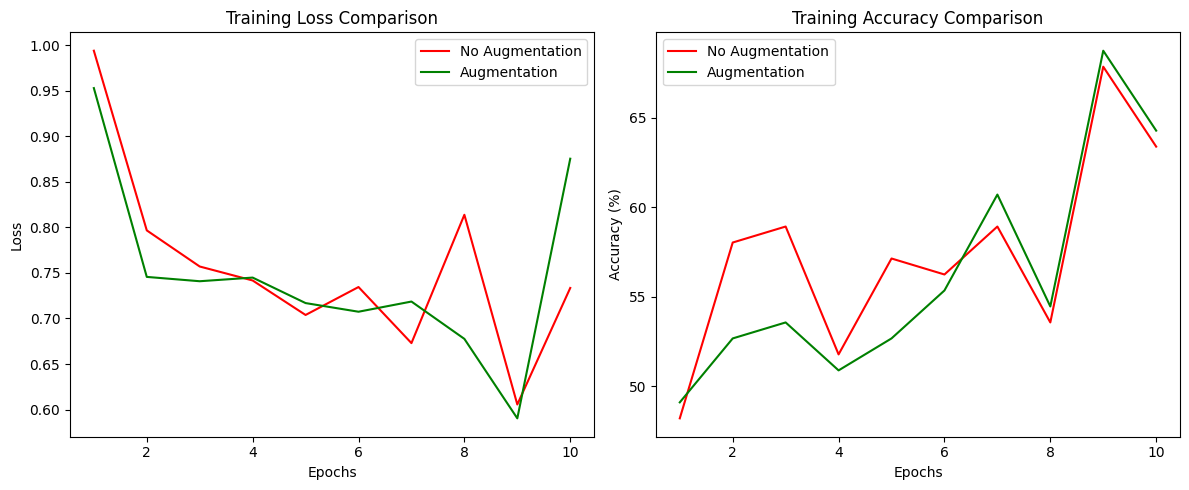

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

# Plot Training Loss
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses_noaug, label='No Augmentation', color='red')
axes[0].plot(range(1, NUM_EPOCHS+1), train_losses_aug, label='Augmentation', color='green')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()

# Plot Training Accuracy
axes[1].plot(range(1, NUM_EPOCHS+1), train_metrics_noaug["accuracy"], label='No Augmentation', color='red')
axes[1].plot(range(1, NUM_EPOCHS+1), train_metrics_aug["accuracy"], label='Augmentation', color='green')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training Accuracy Comparison')
axes[1].legend()

# Adjust layout and display the plots
plt.tight_layout()
plt.show()


## Metrics Comparison

In [ ]:
# Print test metrics for the model trained without augmentation
print("\n Test Metrics for Model without Augmentation:")
for metric, value in test_metrics_noaug.items():
    if metric not in ["labels", "predictions"]:  # Exclude labels & predictions
        print(f"{metric.capitalize()}: {value:.4f}")

# Print test metrics for the model trained with augmentation
print("\n Test Metrics for Model with Augmentation:")
for metric, value in test_metrics_aug.items():
    if metric not in ["labels", "predictions"]:  # Exclude labels & predictions
        print(f"{metric.capitalize()}: {value:.4f}")



 Test Metrics for Model without Augmentation:
Loss: 1.3752
Accuracy: 50.0000
Precision: 0.5000
Recall: 0.5000
F1: 0.4556

 Test Metrics for Model with Augmentation:
Loss: 0.7587
Accuracy: 64.2857
Precision: 0.6556
Recall: 0.6429
F1: 0.6354


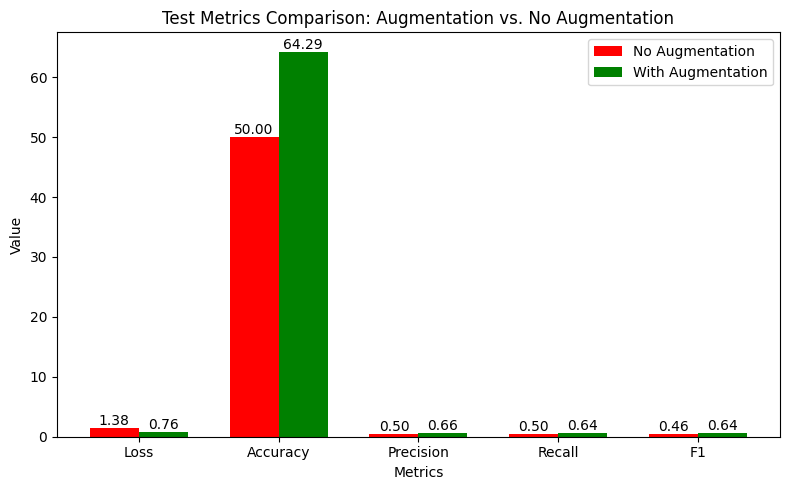

In [ ]:
# Bar plot visualization
metrics_to_plot = ["loss", "accuracy", "precision", "recall", "f1"]
values_noaug = [test_metrics_noaug[m] for m in metrics_to_plot]
values_aug = [test_metrics_aug[m] for m in metrics_to_plot]

x = np.arange(len(metrics_to_plot))  # X-axis positions
width = 0.35  # Width of bars

fig, ax = plt.subplots(figsize=(8, 5))

# Create bars for No Augmentation
bars1 = ax.bar(x - width/2, values_noaug, width, label="No Augmentation", color="red")
# Create bars for With Augmentation
bars2 = ax.bar(x + width/2, values_aug, width, label="With Augmentation", color="green")

# Labels and title
ax.set_xlabel("Metrics")
ax.set_ylabel("Value")
ax.set_title("Test Metrics Comparison: Augmentation vs. No Augmentation")
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in metrics_to_plot])
ax.legend()

# Display values on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.2f}", ha="center", va="bottom")

# Show plot
plt.tight_layout()
plt.show()

## Confusion Matrix

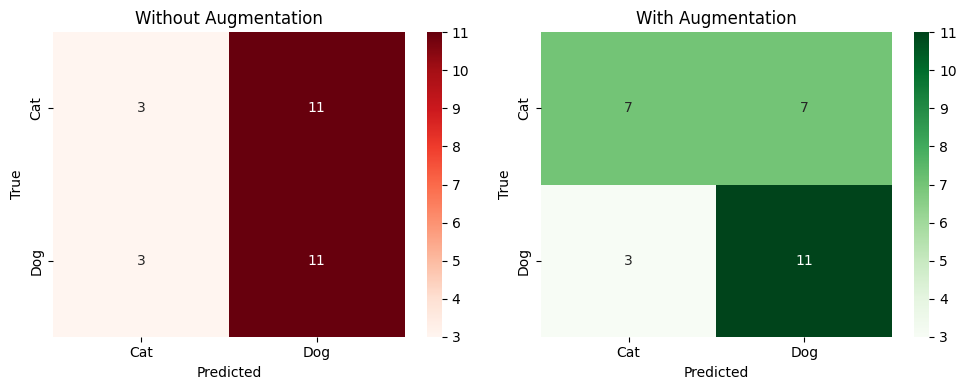

In [ ]:
# Function to plot the confusion matrices
def plot_confusion_matrices(test_metrics_noaug, test_metrics_aug, class_labels=["Cat", "Dog"]):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

    # Without augmentation
    cm_noaug = confusion_matrix(test_metrics_noaug["labels"], test_metrics_noaug["predictions"])
    sns.heatmap(cm_noaug, annot=True, fmt='g', cmap='Reds',
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[0])
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('True')
    axes[0].set_title("Without Augmentation")

    # With augmentation
    cm_aug = confusion_matrix(test_metrics_aug["labels"], test_metrics_aug["predictions"])
    sns.heatmap(cm_aug, annot=True, fmt='g', cmap='Greens',
                xticklabels=class_labels, yticklabels=class_labels, ax=axes[1])
    axes[1].set_xlabel('Predicted')
    axes[1].set_ylabel('True')
    axes[1].set_title("With Augmentation")

    plt.tight_layout()
    plt.show()

# Call the function with updated test metrics
plot_confusion_matrices(test_metrics_noaug, test_metrics_aug)


# Conclusion

**Key Observations**
- The model trained **without augmentation** achieved the following metrics:
  - **Accuracy:** 50.00 %
  - **Precision:** 0.5000
  - **Recall:** 0.5000
  - **F1-score:** 0.4556

- The model trained **with augmentation** achieved **identical** metrics:
  - **Accuracy:** 64.2857 %
  - **Precision:** 0.6556
  - **Recall:** 0.6429
  - **F1-score:** 0.6354


**Analysis**
- The confusion matrix shows that augmentation improves classification, but misclassification of cats remains a challenge.


- **Loss Comparison:** Both models show decreasing loss, but the augmented model (green) is more stable, while the non-augmented model (red) fluctuates more.
- **Accuracy Comparison:** The augmented model improves steadily and achieves higher final accuracy, indicating better generalization.
- Data augmentation helps in stabilizing training and reducing overfitting, leading to better performance.


- **Without Augmentation:** The model misclassifies many cats as dogs, leading to poor accuracy (50%) and an F1-score of 0.4556.
- **With Augmentation:** Accuracy improves to 64.29%, with better precision and recall, showing better generalization.


- We are getting poor accuracy due to a very small test set (28 samples), which may not be sufficient to fully demonstrate the impact of data augmentation.
